In [1]:
!pip install torchinfo

In [2]:
!pip install lightly
!pip install torch-optimizer
!pip install thop >/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="UnsupportedFieldAttributeWarning")

In [4]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

from lightly.transforms import SimCLRTransform
from lightly.transforms.utils import IMAGENET_NORMALIZE

from torch_optimizer import LARS

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [5]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


To ensure fully deterministic behavior across CPU, CUDA, NumPy, and Python’s built-in RNG, we manually fix all random seeds. This helps in achieving consistent results across multiple runs of training, evaluation, and debugging.

In [6]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [7]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [8]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [9]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [10]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/3909389812489563.jpg,Good
1,/kaggle/working/dataset/Good/1168398586939216.jpg,Good
2,/kaggle/working/dataset/Good/1276194056944580.jpg,Good
3,/kaggle/working/dataset/Good/478320457966634.jpg,Good
4,/kaggle/working/dataset/Good/475138847069483.jpg,Good
5,/kaggle/working/dataset/Good/343825380682085.jpg,Good
6,/kaggle/working/dataset/Good/222070386940053.jpg,Good
7,/kaggle/working/dataset/Good/1141403033939415.jpg,Good
8,/kaggle/working/dataset/Good/882312810056519.jpg,Good
9,/kaggle/working/dataset/Good/186183813386458.jpg,Good


This block sets all key file paths for loading the uploaded BYOL checkpoint, saving new checkpoints, tracking loss, and storing embeddings. It also selects the compute device (CPU/GPU) and initializes the main training hyperparameters such as batch size, learning rate, weight decay, and total epochs.

In [11]:
data_dir = "/kaggle/working/dataset"

checkpoint_path = "/kaggle/working/moco_checkpoint.pth"
loss_file = "/kaggle/working/moco_loss.csv"
embedding_path = "/kaggle/working/moco_embeddings.npz"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

training_batch = 32
learning_rate = 0.2 * training_batch / 256
weight_decay = 1.5e-6
start_epoch = 0
total_epochs = 200

This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

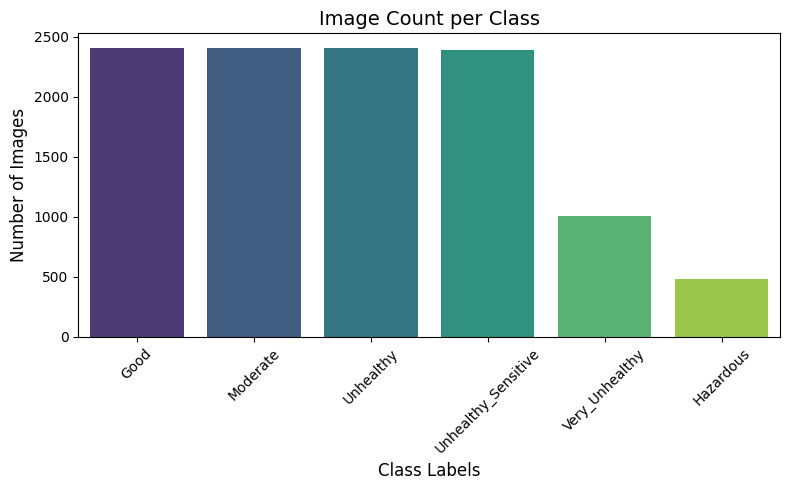

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

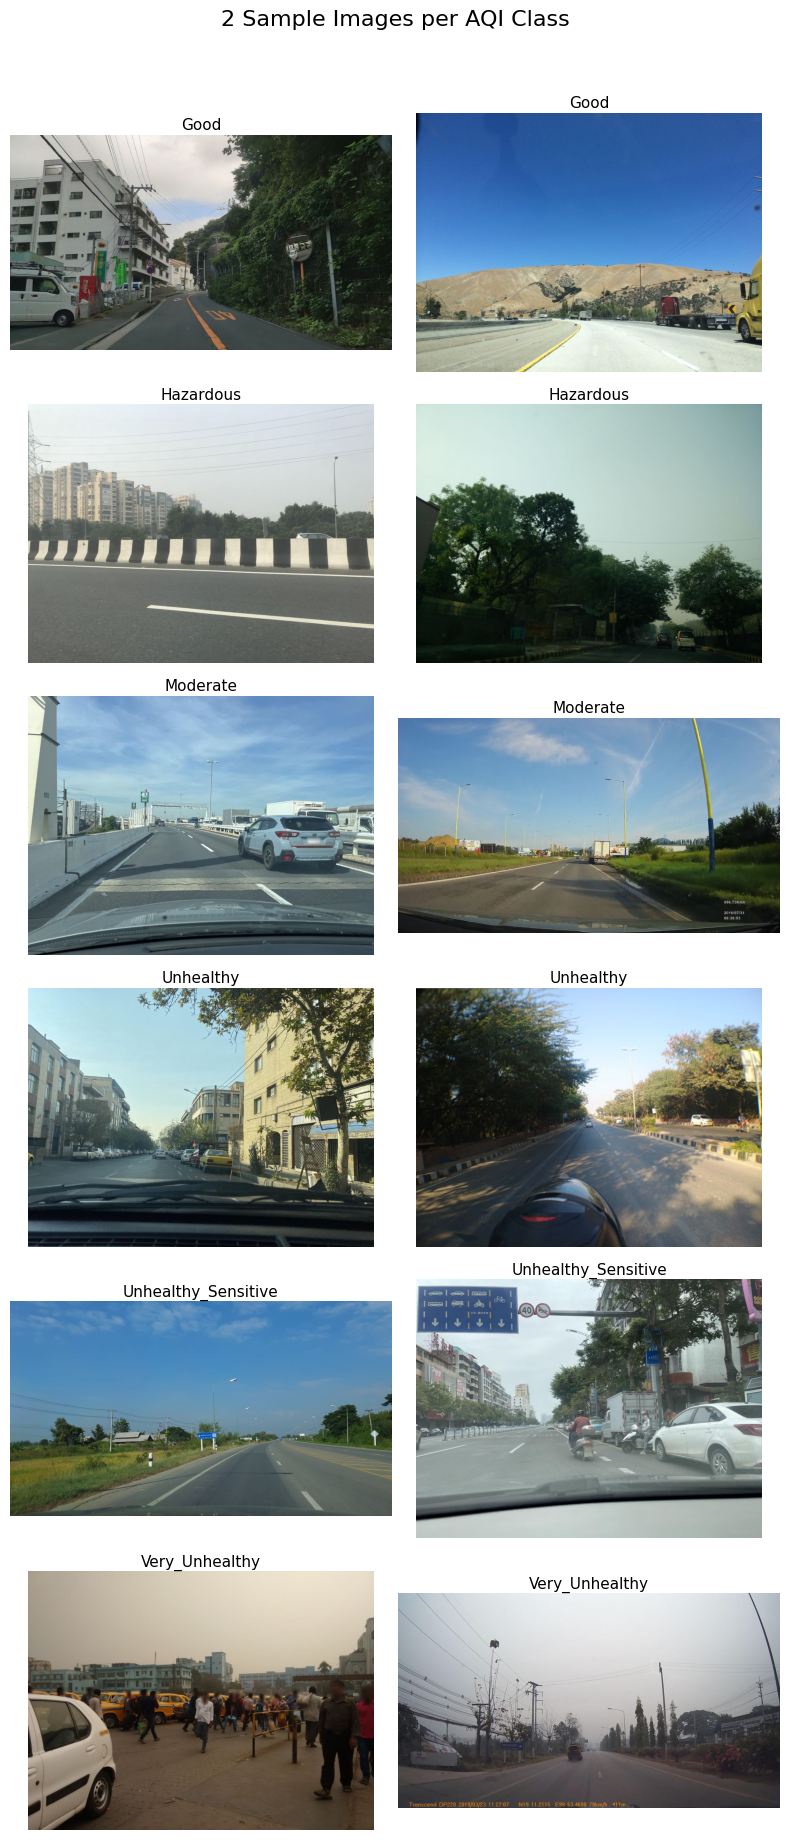

In [13]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This function scans a dataset split directory (train/val/test), collects all image file paths along with their class labels, and returns them as a DataFrame. It also supports optional class filtering, allowing you to load only selected classes when needed.

In [14]:
def load_split(split_dir, selected_classes=None):
    file_paths, labels = [], []
    for class_name in os.listdir(split_dir):
        if selected_classes and class_name not in selected_classes:
            continue
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            for image_name in os.listdir(class_dir):
                file_paths.append(os.path.join(class_dir, image_name))
                labels.append(class_name)
    return pd.DataFrame({"file_path": file_paths, "label": labels})


This block defines the PM2.5 air-quality classes, loads all images belonging to these categories, and prints both the total image count and per-class distribution. It helps verify that the dataset has been correctly loaded and filtered.

In [15]:
PM25_CLASSES = [
    "Good",
    "Moderate",
    "Unhealthy_Sensitive",
    "Unhealthy",
    "Very_Unhealthy",
    "Hazardous"
]

data = load_split(data_dir, selected_classes=PM25_CLASSES)

print("Total images:", len(data))
print(data["label"].value_counts())


Total images: 11103
label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


This block splits the dataset into train, validation, and test sets using stratified sampling to preserve class balance. First, 80% is allocated for training, and the remaining 20% is split evenly into validation and test sets. The sizes of each split are printed for verification.

In [ ]:
from sklearn.model_selection import train_test_split

train_dataframe, temp_dataframe = train_test_split(
    data,
    test_size=0.20,                 
    stratify=data["label"],
    random_state=42
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=0.50,                 
    stratify=temp_dataframe["label"],
    random_state=42
)

print("Train samples:", len(train_dataframe))
print("Validation samples:", len(validation_dataframe))
print("Test samples:", len(test_dataframe))

print("\nTrain label counts:")
print(train_dataframe["label"].value_counts())

print("\nValidation label counts:")
print(validation_dataframe["label"].value_counts())

print("\nTest label counts:")
print(test_dataframe["label"].value_counts())


Train samples: 8882
Validation samples: 1110
Test samples: 1111

Train label counts:
label
Unhealthy              1926
Good                   1926
Moderate               1925
Unhealthy_Sensitive    1914
Very_Unhealthy          806
Hazardous               385
Name: count, dtype: int64

Validation label counts:
label
Moderate               241
Good                   241
Unhealthy              240
Unhealthy_Sensitive    239
Very_Unhealthy         101
Hazardous               48
Name: count, dtype: int64

Test label counts:
label
Good                   241
Unhealthy              241
Moderate               241
Unhealthy_Sensitive    240
Very_Unhealthy         100
Hazardous               48
Name: count, dtype: int64


This block defines a flexible dataset class designed for both self-supervised MoCo training and supervised downstream classification. It reads image file paths, applies the appropriate transformation pipeline, and optionally converts labels into numeric indices when operating in labeled mode. During MoCo pretext training, the dataset produces two independently augmented views of the same image, whereas in supervised mode it returns a single transformed image paired with its corresponding label index. This unified structure provides a consistent and reusable data-loading mechanism across all stages of the model workflow.


In [ ]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, is_lb=False):
        self.file_paths = dataframe["file_path"].tolist()
        self.transform = transform
        self.is_lb = is_lb

        if self.is_lb:
            self.labels = dataframe["label"].tolist()
            classes = sorted(list(set(self.labels)))
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
            self.labels_idx = [self.class_to_idx[l] for l in self.labels]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):
        img_path = self.file_paths[index]
        with Image.open(img_path) as im:
            im = im.convert("RGB")

        if self.transform is not None:
            out = self.transform(im)
        else:
            out = transforms.ToTensor()(im)

        if self.is_lb:
            label = self.labels_idx[index]
            return out, label
        else:
            return out

This block sets up the MoCo augmentation pipeline for self-supervised training. The SimCLRTransform creates two randomly augmented views of each image using cropping, color jitter, flips, and ImageNet normalization. These paired views are required for contrastive learning in the MoCo framework.

In [18]:
moco_transform = SimCLRTransform(
    input_size=224,
    normalize=IMAGENET_NORMALIZE
)


This block prepares the MoCo pretext training dataloader. It builds an unlabeled ImageDataset that applies the contrastive augmentations and returns paired views for each image. The DataLoader then batches and shuffles these samples for efficient self-supervised training.

In [19]:
training_dataset = ImageDataset(
    train_dataframe,
    transform=moco_transform,
    is_lb=False
)

dataloader = DataLoader(
    training_dataset,
    batch_size=training_batch,
    shuffle=True,
    drop_last=True,
    num_workers=2
)


This block visualizes MoCo augmentations by displaying paired views generated for random images in the dataset. For each selected sample, the function shows the query view (x_q) and key view (x_k) side-by-side, allowing verification that the contrastive augmentations are being applied correctly.

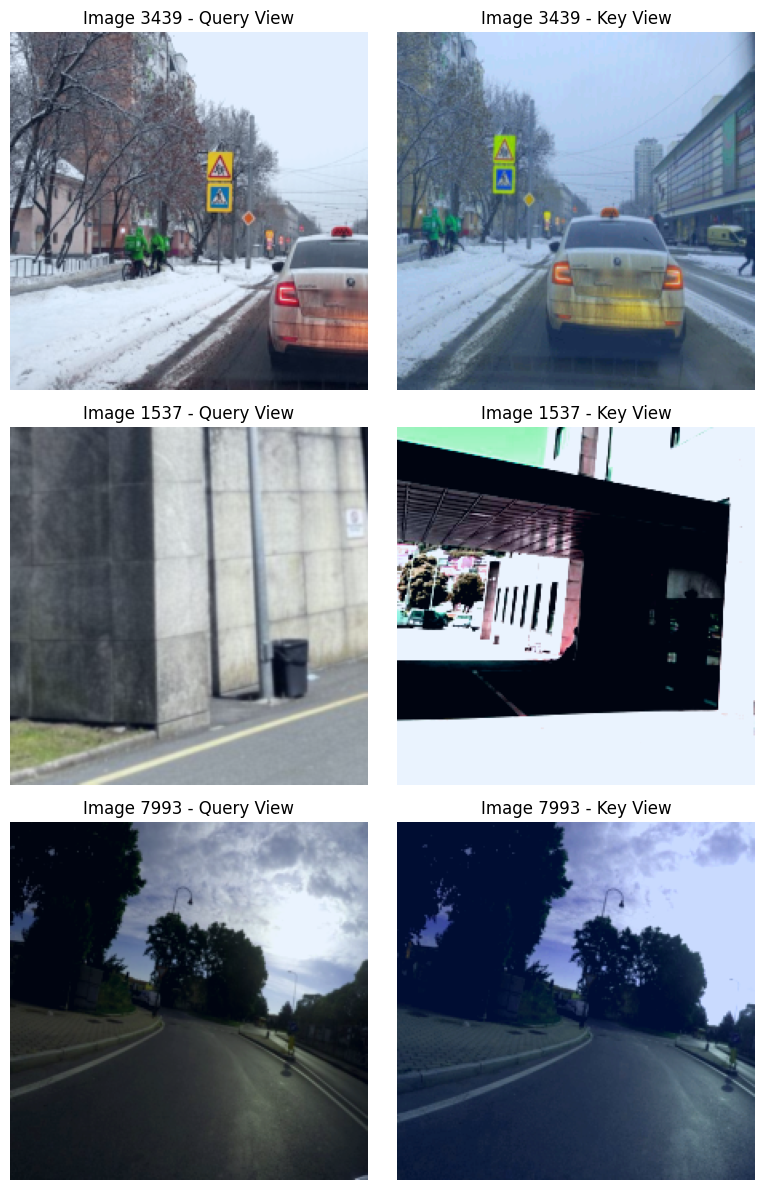

In [20]:
def visualize_moco_views(dataset, num_imgs=5):
    plt.figure(figsize=(8, 4 * num_imgs))
    for i in range(num_imgs):
        idx = random.randint(0, len(dataset) - 1)
        (x_q, x_k) = dataset[idx]

        x_q_np = x_q.permute(1, 2, 0).numpy()
        x_k_np = x_k.permute(1, 2, 0).numpy()

        plt.subplot(num_imgs, 2, 2*i + 1)
        plt.imshow((x_q_np - x_q_np.min()) / (x_q_np.max() - x_q_np.min() + 1e-6))
        plt.axis("off")
        plt.title(f"Image {idx} - Query View")

        plt.subplot(num_imgs, 2, 2*i + 2)
        plt.imshow((x_k_np - x_k_np.min()) / (x_k_np.max() - x_k_np.min() + 1e-6))
        plt.axis("off")
        plt.title(f"Image {idx} - Key View")

    plt.tight_layout()
    plt.show()

visualize_moco_views(training_dataset, num_imgs=3)


This block implements the full MoCo contrastive learning framework. It builds a query encoder and a momentum-updated key encoder, maintains a large dictionary queue of negative samples, and computes InfoNCE logits using positive (q·k) and negative (q·queue) similarities. During each forward pass, the key encoder is updated via momentum, keys are enqueued, older entries are dequeued, and the model returns contrastive logits and labels for training.

In [ ]:
class MoCo(nn.Module):
    def __init__(self, base_encoder, dim=128, K=16384, m=0.999, T=0.2):
        super(MoCo, self).__init__()

        self.K = K            
        self.m = m            
        self.T = T           


        self.encoder_q = base_encoder(num_classes=dim)
        self.encoder_k = base_encoder(num_classes=dim)

        for param_q, param_k in zip(self.encoder_q.parameters(),
                                    self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False     

        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = F.normalize(self.queue, dim=0)

        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for param_q, param_k in zip(self.encoder_q.parameters(),
                                    self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]

        ptr = int(self.queue_ptr)
        assert batch_size <= self.K, "Batch size must be <= K"

        end_ptr = ptr + batch_size

        if end_ptr <= self.K:
            self.queue[:, ptr:end_ptr] = keys.T
        else:
            overflow = end_ptr - self.K
            self.queue[:, ptr:] = keys[:batch_size - overflow].T
            self.queue[:, :overflow] = keys[batch_size - overflow:].T

        self.queue_ptr[0] = end_ptr % self.K

    def forward(self, im_q, im_k):

        q = self.encoder_q(im_q)     
        q = F.normalize(q, dim=1)

        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = self.encoder_k(im_k)
            k = F.normalize(k, dim=1)


        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)

        l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])

        logits = torch.cat([l_pos, l_neg], dim=1)

        logits /= self.T

        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(logits.device)

        self._dequeue_and_enqueue(k)

        return logits, labels


This block builds the MoCo model by using a ResNet-50 backbone as the base encoder. The final fully connected layer is replaced to output the desired embedding dimension for contrastive learning. The MoCo instance is then created with the specified queue size, momentum coefficient, and temperature, and moved to the selected device.

In [ ]:

def resnet50_encoder(num_classes):
    resnet = torchvision.models.resnet50(weights=None)
    resnet.fc = nn.Linear(2048, num_classes)   
    return resnet

model = MoCo(
    base_encoder=resnet50_encoder,
    dim=128,       
    K=16384,       
    m=0.999,       
    T=0.2          
).to(device)

print("MoCo v2 Model Ready")


MoCo v2 Model Ready


This block computes the computational complexity of the MoCo query encoder using a 224×224 dummy input. It measures MACs, GFLOPs, and the total number of parameters using THOP, providing a quick estimate of the model's inference cost and size.

In [23]:
from thop import profile, clever_format

dummy_input = torch.randn(1, 3, 224, 224).to(device)

macs, params = profile(model.encoder_q, inputs=(dummy_input,), verbose=False)
macs, params = clever_format([macs, params], "%.3f")

float_macs = float(macs[:-1])
gflops = float_macs * 2

print("\n[Complexity @224x224]")
print(f"MACs:   {macs}")
print(f"GFLOPs: {gflops:.3f}G")
print(f"Params: {params}")



[Complexity @224x224]
MACs:   4.132G
GFLOPs: 8.264G
Params: 23.770M


This block sets up the MoCo training components by defining the contrastive loss function (cross-entropy) and initializing the LARS optimizer, which is commonly used in large-batch self-supervised training to stabilize and scale the learning process.

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = LARS(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
    momentum=0.9
)


This block performs the full MoCo pretext training loop. It uses mixed-precision training with GradScaler, computes contrastive loss from query–key pairs, updates the model with LARS, and logs the average loss per epoch. Each epoch also saves a checkpoint containing the model, optimizer state, and current loss. The script tracks and prints total training time upon completion.

In [25]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
loss_history = []

with open(loss_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss'])

print("STARTING MOCO TRAINING...")
total_start_time = time.time()

for epoch in range(start_epoch, total_epochs):
    model.train()
    total_loss = 0.0
    epoch_start = time.time()

    for batch in dataloader:
        x_q, x_k = batch
        x_q = x_q.to(device)
        x_k = x_k.to(device)

        with autocast():
            logits, labels = model(x_q, x_k)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    epoch_time = time.time() - epoch_start
    m = int(epoch_time // 60)
    s = int(epoch_time % 60)

    print(f"Epoch [{epoch+1:03d}/{total_epochs}] - Loss: {avg_loss:.5f} - Time: {m}m {s}s")

    with open(loss_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss])

    torch.save(
        {
            'epoch': epoch+1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        },
        checkpoint_path
    )

total_time = time.time() - total_start_time
H = int(total_time // 3600)
M = int((total_time % 3600) // 60)
S = int(total_time % 60)
print(f"\nMOCO TRAINING COMPLETE in {H}h {M}m {S}s")


STARTING MOCO TRAINING...
Epoch [001/200] - Loss: 7.94606 - Time: 2m 13s
Epoch [002/200] - Loss: 8.02457 - Time: 2m 13s
Epoch [003/200] - Loss: 7.55795 - Time: 2m 15s
Epoch [004/200] - Loss: 7.48881 - Time: 2m 13s
Epoch [005/200] - Loss: 7.50885 - Time: 2m 14s
Epoch [006/200] - Loss: 7.58079 - Time: 2m 15s
Epoch [007/200] - Loss: 7.63042 - Time: 2m 14s
Epoch [008/200] - Loss: 7.67610 - Time: 2m 14s
Epoch [009/200] - Loss: 7.73577 - Time: 2m 13s
Epoch [010/200] - Loss: 7.81159 - Time: 2m 12s
Epoch [011/200] - Loss: 7.84848 - Time: 2m 15s
Epoch [012/200] - Loss: 7.86213 - Time: 2m 16s
Epoch [013/200] - Loss: 7.86658 - Time: 2m 12s
Epoch [014/200] - Loss: 7.87760 - Time: 2m 13s
Epoch [015/200] - Loss: 7.88895 - Time: 2m 13s
Epoch [016/200] - Loss: 7.90884 - Time: 2m 12s
Epoch [017/200] - Loss: 7.87675 - Time: 2m 12s
Epoch [018/200] - Loss: 7.88233 - Time: 2m 12s
Epoch [019/200] - Loss: 7.88826 - Time: 2m 13s
Epoch [020/200] - Loss: 7.88757 - Time: 2m 14s
Epoch [021/200] - Loss: 7.87453 - 

This block loads the recorded loss values from the MoCo training log and plots the loss curve across epochs. It provides a visual overview of the training progression and helps verify that the contrastive loss is decreasing as expected.

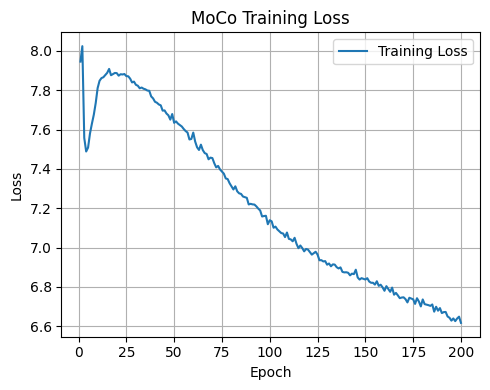

In [26]:
loss_df = pd.read_csv(loss_file)

plt.figure(figsize=(5,4))
plt.plot(loss_df['epoch'], loss_df['loss'], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MoCo Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


This block extracts feature embeddings from the trained MoCo encoder for all labeled training images. Each image is passed through the query encoder using standard evaluation transforms, and the resulting normalized embeddings are collected along with their labels. The final embeddings and labels are saved to disk for downstream classification experiments.

In [27]:
model.eval()

embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_NORMALIZE["mean"],
        std=IMAGENET_NORMALIZE["std"]
    ),
])

embedding_dataset = ImageDataset(
    train_dataframe,
    transform=embedding_transform,
    is_lb=True
)

embedding_loader = DataLoader(
    embedding_dataset,
    batch_size=training_batch,
    shuffle=False,
    num_workers=2
)

def extract_embeddings_moco(model, dataloader, device):
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            feats = model.encoder_q(images)
            feats = F.normalize(feats, dim=1)
            all_embeddings.append(feats.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_embeddings), torch.cat(all_labels)

embeddings, labels = extract_embeddings_moco(model, embedding_loader, device)

np.savez(embedding_path, embeddings=embeddings.numpy(), labels=labels.numpy())

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)


Embeddings shape: torch.Size([8882, 128])
Labels shape: torch.Size([8882])


This block applies t-SNE to project the high-dimensional MoCo embeddings into 2D space for visualization. The resulting scatter plot shows how well the learned representations cluster by class, giving an intuitive view of the feature quality after self-supervised training.

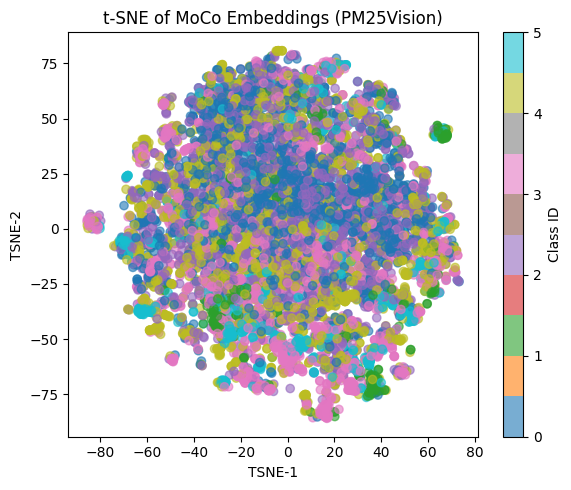

In [28]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings.numpy())

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=labels.numpy(),
    alpha=0.6,
    cmap="tab10"
)
plt.title("t-SNE of MoCo Embeddings (PM25Vision)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter, label="Class ID")
plt.tight_layout()
plt.show()


This block evaluates the quality of MoCo embeddings using unsupervised clustering. KMeans is applied with one cluster per PM2.5 class, and the silhouette score is computed to measure cluster separation. The embeddings are then visualized with t-SNE, colored by cluster ID, to show how well the representations group in feature space.

Silhouette Score (MoCo embeddings, k=6): 0.061136592


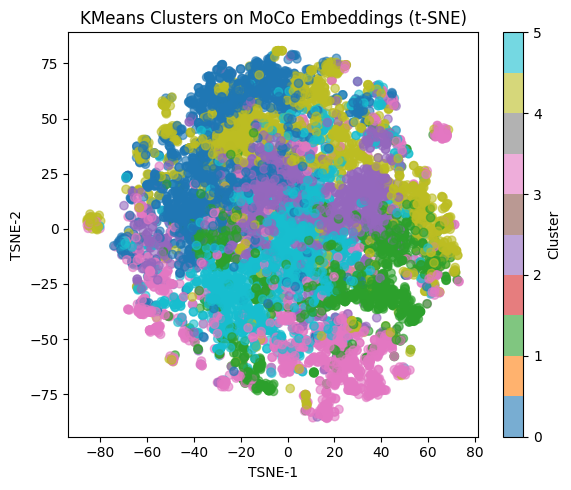

In [29]:
kmeans = KMeans(n_clusters=len(PM25_CLASSES), random_state=42)
cluster_labels = kmeans.fit_predict(embeddings.numpy())

silhouette_avg = silhouette_score(embeddings.numpy(), cluster_labels)
print("Silhouette Score (MoCo embeddings, k=6):", silhouette_avg)

tsne_clusters = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d_c = tsne_clusters.fit_transform(embeddings.numpy())

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    emb_2d_c[:,0],
    emb_2d_c[:,1],
    c=cluster_labels,
    alpha=0.6,
    cmap="tab10"
)
plt.title("KMeans Clusters on MoCo Embeddings (t-SNE)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()
